In [5]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()


Train shape: (26570, 26)
Test shape: (20775, 25)


,id,product_code,loading,attribute_0,attribute_1,attribute_2,attribute_3,measurement_0,measurement_1,measurement_2,...,measurement_9,measurement_10,measurement_11,measurement_12,measurement_13,measurement_14,measurement_15,measurement_16,measurement_17,failure
0,0,A,80.10,material_7,material_8,9,5,7,8,4,...,10.672,15.859,17.594,15.193,15.029,NaN,13.034,14.684,764.100,0
1,1,A,84.89,material_7,material_8,9,5,14,3,3,...,12.448,17.947,17.915,11.755,14.732,15.425,14.395,15.631,682.057,0
2,2,A,82.43,material_7,material_8,9,5,12,1,5,...,12.715,15.607,NaN,13.798,16.711,18.631,14.094,17.946,663.376,0
3,3,A,101.07,material_7,material_8,9,5,13,2,6,...,12.471,16.346,18.377,10.020,15.250,15.562,16.154,17.172,826.282,0
4,4,A,188.06,material_7,material_8,9,5,9,2,8,...,10.337,17.082,19.932,12.428,16.182,12.760,13.153,16.412,579.885,0


In [6]:
print("Train codes:", sorted(train["product_code"].unique()))
print("Test codes:", sorted(test["product_code"].unique()))


Train codes: ['A', 'B', 'C', 'D', 'E']
Test codes: ['F', 'G', 'H', 'I']


Tarea 1: Predicción de Fallos
El objetivo es construir un modelo de clasificación binaria supervisada que permita estimar la probabilidad de fallo en nuevos productos a partir de sus atributos y mediciones.

El modelo aprende patrones a partir de los datos históricos (train.csv) y los aplica posteriormente a productos nuevos (test.csv).

En términos simples, el modelo responde a la siguiente pregunta:

Dadas estas mediciones y características, ¿cuál es la probabilidad de que el producto falle?

Se trata de un problema clásico de clasificación con datos tabulares.

In [8]:
# TASK 1 — XGBoost + CV + métricas (arreglando columnas str: attribute_0/1)

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

# 1) Cargar train
train = pd.read_csv("../data/train.csv")

# 2) Separar X/y
X = train.drop(columns=["failure"])
y = train["failure"]

# 3) Quitar product_code (en tu split train/test son códigos distintos)
if "product_code" in X.columns:
    X = X.drop(columns=["product_code"])

# 4) Convertir columnas tipo object/str a category (XGBoost puede manejarlas si enable_categorical=True)
obj_cols = X.select_dtypes(include=["object"]).columns.tolist()
for c in obj_cols:
    X[c] = X[c].astype("category")

print("Columnas categóricas convertidas:", obj_cols)

# 5) Modelo base
model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    enable_categorical=True,   # <- clave
    tree_method="hist"         # <- recomendado con categóricas
)

# 6) Validación cruzada + métricas
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1",
}

results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score="raise"
)

def summarize(metric):
    vals = results[f"test_{metric}"]
    return float(np.mean(vals)), float(np.std(vals)), vals

roc_mean, roc_std, roc_vals = summarize("roc_auc")
acc_mean, acc_std, acc_vals = summarize("accuracy")
f1_mean,  f1_std,  f1_vals  = summarize("f1")

print("\n=== TASK 1: XGBoost + Stratified 5-Fold CV ===")
print(f"ROC-AUC : mean={roc_mean:.4f} | std={roc_std:.4f} | folds={np.round(roc_vals, 4)}")
print(f"Accuracy: mean={acc_mean:.4f} | std={acc_std:.4f} | folds={np.round(acc_vals, 4)}")
print(f"F1      : mean={f1_mean:.4f} | std={f1_std:.4f} | folds={np.round(f1_vals, 4)}")

C:\Users\alber\AppData\Local\Temp\ipykernel_33004\1799298384.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X.select_dtypes(include=["object"]).columns.tolist()


Columnas categóricas convertidas: ['attribute_0', 'attribute_1']

=== TASK 1: XGBoost + Stratified 5-Fold CV ===
ROC-AUC : mean=0.5509 | std=0.0043 | folds=[0.5487 0.5594 0.5494 0.5476 0.5496]
Accuracy: mean=0.7856 | std=0.0007 | folds=[0.7849 0.7866 0.7851 0.7851 0.7864]
F1      : mean=0.0210 | std=0.0054 | folds=[0.0155 0.0308 0.0189 0.0172 0.0224]


## Task 1 — Modelo Base (XGBoost)

Se entrenó un modelo XGBoost utilizando validación cruzada estratificada (5 folds).

### Resultados principales:

- **ROC-AUC medio:** 0.551  
- **Accuracy media:** 0.786  
- **F1-score medio:** 0.021  

### Interpretación:

Aunque la **accuracy (~78.6%)** parece elevada, esta métrica no es adecuada en este caso debido al fuerte desbalance del dataset (la mayoría de los productos no fallan).

El valor de **ROC-AUC (~0.55)** indica que el modelo apenas mejora respecto a una predicción aleatoria (0.5), lo que sugiere que las variables disponibles tienen capacidad limitada para discriminar entre productos que fallan y los que no.

El **F1-score extremadamente bajo (~0.02)** confirma que el modelo apenas está identificando correctamente los casos positivos (fallos).

En conclusión, el modelo base tiene una capacidad predictiva limitada, aunque sirve como punto de partida para el análisis.

Tarea 2: Evaluación de Data Drift
Una vez entrenado el modelo, es necesario comprobar si los datos nuevos siguen la misma distribución que los datos históricos.

Si la distribución cambia (data drift), el rendimiento del modelo puede deteriorarse.

Para evaluar este posible drift:

Se combinan los datos de entrenamiento y prueba
Se etiqueta cada registro según su origen (train = 0, test = 1)
Se entrena un modelo que intente distinguir entre ambos
Si el modelo logra diferenciarlos fácilmente, existe data drift.
Si no puede distinguirlos (rendimiento cercano al azar), ambos conjuntos son estadísticamente homogéneos.

=== Drift categórico: product_code ===
Train codes: ['A', 'B', 'C', 'D', 'E']
Test  codes: ['F', 'G', 'H', 'I']
Solapamiento: []
Conclusión: hay drift categórico fuerte (test contiene categorías no vistas en train).

Columnas numéricas comunes: 22
['id', 'loading', 'attribute_2', 'attribute_3', 'measurement_0', 'measurement_1', 'measurement_2', 'measurement_3', 'measurement_4', 'measurement_5', 'measurement_6', 'measurement_7', 'measurement_8', 'measurement_9', 'measurement_10', 'measurement_11', 'measurement_12', 'measurement_13', 'measurement_14', 'measurement_15'] ...

=== Top 10 variables con mayor diferencia absoluta de media (test vs train) ===


,col,train_mean,test_mean,train_median,test_median,train_std,test_std,train_null_%,test_null_%,abs_mean_diff
0,id,13284.500000,36957.000000,13284.5000,36957.000,7670.242662,5997.370257,0.000000,0.000000,23672.500000
3,attribute_3,7.240459,6.196823,8.0000,5.000,1.456493,1.917478,0.000000,0.000000,1.043636
2,attribute_2,6.754046,7.733959,6.0000,7.000,1.471852,1.308535,0.000000,0.000000,0.979913
5,measurement_1,8.232518,8.962407,8.0000,9.000,4.199401,4.334200,0.000000,0.000000,0.729889
15,measurement_11,19.172085,18.846571,19.2115,18.810,1.520785,1.588642,5.525028,5.468111,0.325514
16,measurement_12,11.702464,11.914230,11.7170,11.941,1.488838,1.363253,6.025593,5.968712,0.211765
1,loading,127.826233,127.634895,122.3900,122.110,39.030020,39.154642,0.940911,1.073406,0.191337
20,measurement_16,16.460727,16.636052,16.4360,16.706,1.708935,1.643463,7.941287,8.077016,0.175325
6,measurement_2,6.256568,6.126931,6.0000,6.000,3.309109,3.835881,0.000000,0.000000,0.129636
21,measurement_17,701.269059,701.389816,701.0245,701.379,123.304161,130.205829,8.596161,8.375451,0.120758



=== PSI (Top 15) ===


C:\Users\alber\AppData\Local\Temp\ipykernel_33004\1885567816.py:78: RuntimeWarning: invalid value encountered in divide
  te_pct = te_counts / te_counts.sum()


,col,psi
2,attribute_2,2.719133
3,attribute_3,0.344834
15,measurement_11,0.056347
16,measurement_12,0.046605
17,measurement_13,0.040793
5,measurement_1,0.031823
6,measurement_2,0.031623
18,measurement_14,0.020829
14,measurement_10,0.020670
4,measurement_0,0.019127


Guía PSI (orientativa): <0.1 bajo | 0.1–0.25 moderado | >0.25 alto



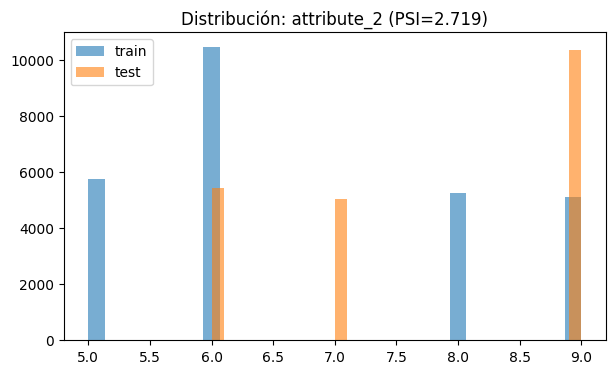

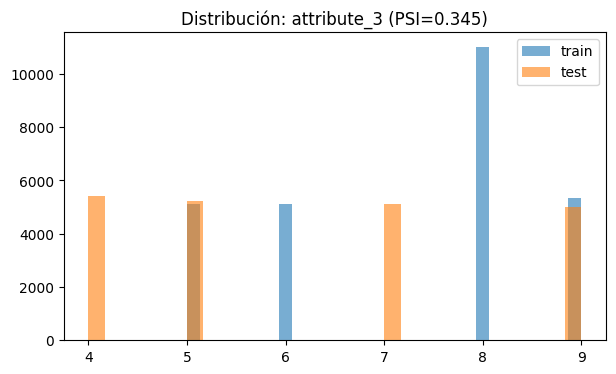

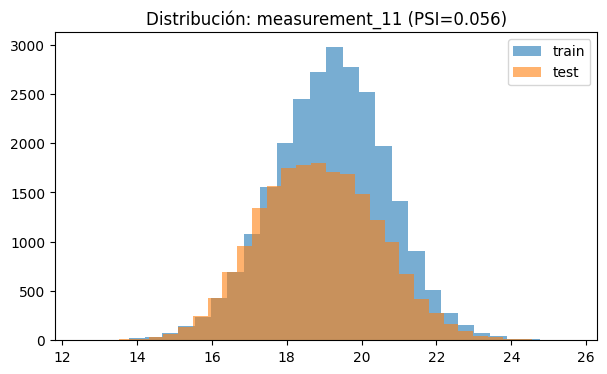

In [10]:
# TASK 2 — Evaluar data drift (train vs test) en 1 celda
# (comparación numéricas + drift categórico de product_code + PSI)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

# --- 1) Drift categórico: product_code ---
if "product_code" in train.columns and "product_code" in test.columns:
    train_codes = sorted(train["product_code"].dropna().unique())
    test_codes  = sorted(test["product_code"].dropna().unique())
    overlap = sorted(set(train_codes) & set(test_codes))
    print("=== Drift categórico: product_code ===")
    print("Train codes:", train_codes)
    print("Test  codes:", test_codes)
    print("Solapamiento:", overlap)
    if len(overlap) == 0:
        print("Conclusión: hay drift categórico fuerte (test contiene categorías no vistas en train).")
    print()

# --- 2) Selección de columnas numéricas comunes ---
num_train = train.select_dtypes(include=[np.number]).copy()
num_test  = test.select_dtypes(include=[np.number]).copy()

# quitar target si está en numéricas
if "failure" in num_train.columns:
    num_train = num_train.drop(columns=["failure"])

common_num_cols = [c for c in num_train.columns if c in num_test.columns]
print("Columnas numéricas comunes:", len(common_num_cols))
print(common_num_cols[:20], "..." if len(common_num_cols) > 20 else "")
print()

# --- 3) Resumen estadístico comparativo (mediana/media/std) ---
summary = []
for c in common_num_cols:
    tr = num_train[c]
    te = num_test[c]
    summary.append({
        "col": c,
        "train_mean": tr.mean(),
        "test_mean": te.mean(),
        "train_median": tr.median(),
        "test_median": te.median(),
        "train_std": tr.std(),
        "test_std": te.std(),
        "train_null_%": tr.isna().mean() * 100,
        "test_null_%": te.isna().mean() * 100,
    })

summary_df = pd.DataFrame(summary)
summary_df["abs_mean_diff"] = (summary_df["test_mean"] - summary_df["train_mean"]).abs()
summary_df = summary_df.sort_values("abs_mean_diff", ascending=False)

print("=== Top 10 variables con mayor diferencia absoluta de media (test vs train) ===")
display(summary_df.head(10))

# --- 4) PSI (Population Stability Index) por variable ---
def psi(train_s, test_s, bins=10):
    tr = train_s.dropna().to_numpy()
    te = test_s.dropna().to_numpy()
    if len(tr) == 0 or len(te) == 0:
        return np.nan

    # cortes por cuantiles del TRAIN para comparar contra TEST
    q = np.linspace(0, 1, bins + 1)
    breaks = np.unique(np.quantile(tr, q))
    if len(breaks) < 3:
        return 0.0  # variable casi constante

    tr_counts, _ = np.histogram(tr, bins=breaks)
    te_counts, _ = np.histogram(te, bins=breaks)

    tr_pct = tr_counts / tr_counts.sum()
    te_pct = te_counts / te_counts.sum()

    # evitar ceros
    eps = 1e-6
    tr_pct = np.clip(tr_pct, eps, 1)
    te_pct = np.clip(te_pct, eps, 1)

    return float(np.sum((te_pct - tr_pct) * np.log(te_pct / tr_pct)))

psi_rows = []
for c in common_num_cols:
    psi_rows.append({"col": c, "psi": psi(num_train[c], num_test[c], bins=10)})

psi_df = pd.DataFrame(psi_rows).sort_values("psi", ascending=False)

print("\n=== PSI (Top 15) ===")
display(psi_df.head(15))

# umbrales típicos (orientativos)
print("Guía PSI (orientativa): <0.1 bajo | 0.1–0.25 moderado | >0.25 alto")
print()

# --- 5) Gráficos rápidos de las 3 variables con PSI más alto ---
top_cols = psi_df["col"].head(3).tolist()
for c in top_cols:
    plt.figure(figsize=(7,4))
    plt.hist(num_train[c].dropna(), bins=30, alpha=0.6, label="train")
    plt.hist(num_test[c].dropna(),  bins=30, alpha=0.6, label="test")
    plt.title(f"Distribución: {c} (PSI={psi_df.loc[psi_df['col']==c,'psi'].values[0]:.3f})")
    plt.legend()
    plt.show()
